# Tufa Labs ARC3 submission

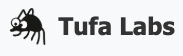

**Note**: this notebook is a more readable version of the notebook that scored our milestone-winning 1.21; unfortunately, we haven't had the same lucky result with this one. The original one is also shared here, but using it is not recommended: https://www.kaggle.com/code/jeroencottaar/taaf-duck-harness-kaggle

**Note**: if you make a copy of this notebook, you will have to manually select the proper GPU (RTX Pro 6000).

Link to writeup explaining what's going on here: https://www.kaggle.com/competitions/arc-prize-2026-arc-agi-3/discussion/717133

Link to Machine Learning Street Talk interview by Tim Scarfe about this duck harness: https://x.com/MLStreetTalk/status/2072326433922297975?s=20

This notebook executes the ARC-AGI-3 solver written by the Tufa Labs team; in alphabetical order: Harold Bessis, Jeroen Cottaar, Isaiah Pressman, Andries Smit, Michal Tesnar, and Stefano Viel.

You will only find infrastructure and diagnostics in this notebook; the actual solver code is in an attached dataset. See our writeup on the competition forum to learn more about that the solver actually does.

It installs the ARC runtime from the competition wheelhouse, makes the bundled source
snapshot importable, runs any solver setup commands, loads the pickled benchmark, plays the
competition games, and writes results to `/kaggle/working`. Diagnostics are minimised during
a real competition rerun (`KAGGLE_IS_COMPETITION_RERUN`) and kept full otherwise.

## 1. Environment and submission mode

Detect whether this is a real competition rerun (which minimises diagnostics), set the
framework's environment flags, and put the CUDA libraries on the linker path.

In [ ]:
import json
import os
import pickle
import subprocess
import sys
import sysconfig
import time
from datetime import datetime, timedelta
from pathlib import Path
from urllib.request import urlopen

# True only inside a real competition rerun; switches diagnostics + soft deadline.
TRUE_SUBMISSION = os.environ.get("KAGGLE_IS_COMPETITION_RERUN", "").strip().lower() in {"1", "true"}
NOTEBOOK_START_EPOCH = time.time()

# Non-interactive matplotlib backend: diagnostics render plots with no display attached.
os.environ["MPLBACKEND"] = "Agg"
# Marks the run as a (real or emulated) submission so the framework + solver can adjust.
os.environ["TAAF_RUN_AS_SUBMISSION"] = "1" if TRUE_SUBMISSION else "0"
# In submission, disable the periodic JSON/HTML diagnostics writes and per-frame logging.
os.environ["TAAF_MINIMAL_DIAGNOSTICS"] = "1" if TRUE_SUBMISSION else "0"
# Pin arc_agi's cached level_reset_only before its client is built (RESET keeps the level).
os.environ["ONLY_RESET_LEVELS"] = "true"

# Prepend the CUDA toolkit to the linker path (it is off it on Kaggle GPU images) so the
# solver's GPU libraries (e.g. vllm / torch) can link against libcuda.
cuda_library_path = "/usr/local/nvidia/lib64"
os.environ["LIBRARY_PATH"] = os.pathsep.join(
    entry for entry in [cuda_library_path, *os.environ.get("LIBRARY_PATH", "").split(os.pathsep)] if entry
)

# Everything the run produces is written here.
WORKING_DIR = Path("/kaggle/working")
WORKING_DIR.mkdir(parents=True, exist_ok=True)
print(f"taaf.kaggle: TRUE_SUBMISSION={TRUE_SUBMISSION}")

## 2. Install the ARC runtime

Install `arc-agi` from the offline competition wheelhouse (the Kaggle submission environment
has no internet).

In [ ]:
# patch-closure: install the ARC runtime from the bundled competition wheels.
# The competition data mounts at EITHER /kaggle/input/competitions/<slug> OR
# /kaggle/input/<slug> depending on the machine (proven from pip's stderr on
# the 2026-08-08 candidate ERRORs). Probe both; fail loudly naming both.
_pc_wheel_dirs = [
    "/kaggle/input/competitions/arc-prize-2026-arc-agi-3/arc_agi_3_wheels",
    "/kaggle/input/arc-prize-2026-arc-agi-3/arc_agi_3_wheels",
]
_pc_wheels = next((p for p in _pc_wheel_dirs if Path(p).is_dir()), None)
if _pc_wheels is None:
    raise RuntimeError(
        f"arc_agi_3_wheels directory not found at either mount form: {_pc_wheel_dirs}")
print(f"[pc] installing arc-agi from {_pc_wheels}", flush=True)
_pc_pip = subprocess.run(
    [
        sys.executable, "-m", "pip", "install",
        "--quiet", "--no-index", "--no-warn-conflicts",
        "--disable-pip-version-check",
        "--find-links", _pc_wheels,
        "arc-agi",
    ],
    capture_output=True, text=True,
)
if _pc_pip.stdout.strip():
    print(_pc_pip.stdout, flush=True)
if _pc_pip.stderr.strip():
    print(f"[pc] pip stderr:\n{_pc_pip.stderr}", flush=True)
if _pc_pip.returncode != 0:
    raise RuntimeError(f"[pc] pip install of arc-agi FAILED (rc={_pc_pip.returncode})")
print(f"[pc] arc-agi installed from {_pc_wheels}", flush=True)


## 3. Locate the source bundle

Find the uploaded TAAF source dataset by its marker file, and record where Kaggle mounted
every attached input so setup commands and the solver can find them.

In [ ]:
# Kaggle inputs attached to this notebook, plus bookkeeping paths used below.
DATASET_SOURCES = ["jeroencottaar/taaf-kaggle-source-share", "driessmit1/arc3-vllm-h100-wheelhouse-v3", "ahmedmobasher86/redhatai-qwen3-6-27b-fp8-hf-snapshot"]
KERNEL_SOURCES = []
DATASET_BUNDLE_MARKER = "taaf-kaggle-bundle.json"
SETUP_ENV_PATH = WORKING_DIR / "taaf_setup_env.json"


# Locate the source dataset by its marker file rather than a fixed mount path.
def _find_bundle_dir() -> Path:
    for marker in Path("/kaggle/input").rglob(DATASET_BUNDLE_MARKER):
        return marker.parent
    raise RuntimeError("TAAF source bundle not found under /kaggle/input.")


# Kaggle mounts a dataset at /kaggle/input/<slug> or /kaggle/input/datasets/<owner>/<slug>
# (depending on owner / slug collisions), so probe both and use whichever exists. Utility
# scripts mount under /kaggle/usr/lib/notebooks/<owner>/<slug>.
def _dataset_mount_candidates(ref: str) -> list[Path]:
    owner, slug = ref.split("/", 1)
    return [Path("/kaggle/input") / slug, Path("/kaggle/input/datasets") / owner / slug]


def _kernel_mount_candidates(ref: str) -> list[Path]:
    owner, slug = ref.split("/", 1)
    return [Path("/kaggle/usr/lib/notebooks") / owner / slug]


def _first_existing(candidates: list[Path]) -> Path | None:
    return next((c for c in candidates if c.exists()), None)


BUNDLE_DIR = _find_bundle_dir()
print(f"taaf.kaggle: source bundle = {BUNDLE_DIR}")

# Map each attached input to where Kaggle actually mounted it (the source bundle is index 0).
kaggle_input_paths: dict[str, str] = {}
for i, ref in enumerate(DATASET_SOURCES):
    candidates = _dataset_mount_candidates(ref)
    resolved = BUNDLE_DIR if i == 0 else _first_existing(candidates)
    kaggle_input_paths[ref] = str(resolved or candidates[0])
for ref in KERNEL_SOURCES:
    candidates = _kernel_mount_candidates(ref)
    kaggle_input_paths[ref] = str(_first_existing(candidates) or candidates[0])

# Published to setup commands and the solver via the environment:
setup_env = {
    # JSON {ref: mount_path} so they can locate every attached dataset / utility script.
    "TAAF_KAGGLE_INPUT_PATHS": json.dumps(kaggle_input_paths, sort_keys=True),
    # The attached dataset refs in order (index 0 is this source bundle).
    "TAAF_KAGGLE_DATASET_SOURCES": json.dumps(DATASET_SOURCES),
    # The attached utility-script / kernel refs.
    "TAAF_KAGGLE_KERNEL_SOURCES": json.dumps(KERNEL_SOURCES),
}
os.environ.update(setup_env)
SETUP_ENV_PATH.write_text(json.dumps(setup_env, indent=2, sort_keys=True) + "\n")
print(f"taaf.kaggle: input paths = {setup_env['TAAF_KAGGLE_INPUT_PATHS']}")

## 4. Import the bundled source and run solver setup

Put the snapshotted repositories on the path (this process and any child processes), then run
the solver's setup commands — installing wheels, fetching model weights, and so on.

In [ ]:
# Each bundled repo exposes its importable tree at <repo>/src or <repo>.
def _source_path_entries(bundle_dir: Path) -> list:
    entries = []
    for repo in sorted((bundle_dir / "src").iterdir(), reverse=True):
        for candidate in (repo / "src", repo):
            if candidate.is_dir():
                entries.append(candidate)
    return entries


# Environment handed to each setup command (paths + any keys it has persisted).
def _command_env() -> dict:
    env = os.environ.copy()
    # "$PYTHON" in a command resolves to this notebook's interpreter.
    env["PYTHON"] = sys.executable
    # Absolute path to the mounted source bundle.
    env["TAAF_KAGGLE_BUNDLE_DIR"] = str(BUNDLE_DIR)
    # The writable /kaggle/working directory.
    env["TAAF_KAGGLE_WORKING_DIR"] = str(WORKING_DIR)
    # A command writes a JSON object here to persist env keys to later commands + the run.
    env["TAAF_KAGGLE_SETUP_ENV"] = str(SETUP_ENV_PATH)
    env.update({str(k): str(v) for k, v in json.loads(SETUP_ENV_PATH.read_text()).items()})
    return env


# Make the bundled repos importable here (sys.path) and in child processes (.pth).
source_entries = _source_path_entries(BUNDLE_DIR)
for entry in source_entries:
    sys.path.insert(0, str(entry))
pth_path = Path(sysconfig.get_paths()["purelib"]) / "taaf_kaggle_sources.pth"
pth_path.write_text("".join(f"{entry}\n" for entry in source_entries))
print(f"taaf.kaggle: wrote {pth_path} ({len(source_entries)} source roots)")

# Solver setup commands (wheels, vLLM server startup, ...) run before the benchmark loads.
env = _command_env()
if True:  # patch-closure: force the serve — a commit run must serve Qwen
    # QUANT arm (build_quant_screen.py): swap the served FP8 snapshot
    # IN-MEMORY before any setup command runs. setup_commands.json is
    # mounted read-only and hardcodes the vrfai snapshot; each anchor must
    # fire exactly once or we abort HERE — this arm must never silently
    # serve vrfai (the whole treatment would vanish unmeasured).
    _pc_quant_anchors = [
        ("MODEL_OWNER = 'driessmit1'",
         "MODEL_OWNER = 'ahmedmobasher86'"),
        ("MODEL_SLUG = 'vrfai-qwen3-6-27b-fp8-hf-snapshot'",
         "MODEL_SLUG = 'redhatai-qwen3-6-27b-fp8-hf-snapshot'"),
        ("SERVED_MODEL_NAME = 'vrfai/Qwen3.6-27B-FP8'",
         "SERVED_MODEL_NAME = 'RedHatAI/Qwen3.6-27B-FP8'"),
    ]
    _pc_quant_commands = json.loads((BUNDLE_DIR / "setup_commands.json").read_text())
    _pc_quant_fired = {old: 0 for old, _new in _pc_quant_anchors}
    _pc_quant_rewritten = []
    for command in _pc_quant_commands:
        for _old, _new in _pc_quant_anchors:
            _pc_quant_fired[_old] += command.count(_old)
            command = command.replace(_old, _new)
        _pc_quant_rewritten.append(command)
    if any(n != 1 for n in _pc_quant_fired.values()):
        raise RuntimeError(
            "[pc] QUANT serve-anchor rewrite did NOT fire exactly once per "
            f"anchor: {_pc_quant_fired} — anchor drift in setup_commands.json; "
            "refusing to run any setup command (a silent vrfai serve "
            "measures nothing)")
    print("[pc] QUANT serve anchors rewritten vrfai -> RedHatAI "
          f"(fired: {_pc_quant_fired})", flush=True)
    for command in _pc_quant_rewritten:
        print(f"taaf.kaggle: setup command: {command}", flush=True)
        subprocess.run(command, shell=True, check=True, cwd=WORKING_DIR, env=env)
        env = _command_env()
        os.environ.update(env)
else:
    print("[duck] commit: skipping setup_commands (no GPU serve)", flush=True)

# Honour any PYTHONPATH a setup command exported.
for entry in reversed([e for e in os.environ.get("PYTHONPATH", "").split(os.pathsep) if e]):
    if entry not in sys.path:
        sys.path.insert(0, entry)

## 5. Load the benchmark

Unpickle the deployment target and the benchmark, stamping the real submission state onto the
target and pointing the benchmark's outputs at the Kaggle working directory.

In [ ]:
# Restore the deployment target and record the real submission state on it.
with open(BUNDLE_DIR / "deploy_target.pkl", "rb") as file:
    target = pickle.load(file)
target.actual_run_as_submission = TRUE_SUBMISSION
target.is_competition_rerun = TRUE_SUBMISSION

# Restore the benchmark and point its outputs at the Kaggle working dir.
with open(BUNDLE_DIR / "benchmark_initial.pkl", "rb") as file:
    bm = pickle.load(file)
bm.job_dir = WORKING_DIR

## 6. Customization hook

Optional: tweak `bm`, `bm.games`, or `bm.solver` here before the run starts — the safe place
for one-off experiments once the deployed bundle has loaded.

In [ ]:
# ============================================================================
# Patch-closure machinery, arm: QUANT. The SHIPPED config (duck-base v2: NO
# duck_patches inlined, NO apply_all) with ONE build-time treatment: the
# served FP8 snapshot is swapped vrfai -> RedHatAI (dataset mount + cell-6
# DATASET_SOURCES + in-memory serve-anchor rewrite in the setup loop).
# Built by build_quant_screen.py — edit there and rebuild.
# ============================================================================
# --- ANTI-APPLY GUARD: the mirror image of the patched arms' APPLY_BLOCK ----
# A build regression that leaks the patch layer into this arm must die HERE,
# before any GPU minute is spent.
import sys as _pc_guard_sys
_pc_guard_forbidden = [
    _sym for _sym in (
        "apply_all", "patch_action7", "patch_watchdog", "patch_hud_board_identity",
        "patch_win_replay", "patch_frontier_graph", "HudMaskTracker",
        "ANTIFREEZE_DIAGNOSTICS")
    if _sym in globals()]
if _pc_guard_forbidden or "duck_patches" in _pc_guard_sys.modules:
    raise RuntimeError(
        "[pc] QUANT arm is contaminated with patch symbols: "
        f"globals={_pc_guard_forbidden} "
        f"duck_patches_module={'duck_patches' in _pc_guard_sys.modules}")
from inference.framework import solver as _pc_guard_sv
_pc_guard_cls = _pc_guard_sv._HarnessGameSession
_pc_guard_markers = {
    _name: [_attr for _attr in vars(_fn) if _attr.endswith("_patched")]
    for _name, _fn in (
        ("should_stop", _pc_guard_cls.should_stop),
        ("step_env", _pc_guard_cls.step_env),
        ("_execute_action", _pc_guard_cls._execute_action),
        ("play", _pc_guard_cls.play))}
_pc_guard_markers = {k: v for k, v in _pc_guard_markers.items() if v}
if _pc_guard_markers:
    raise RuntimeError(
        f"[pc] QUANT arm: live classes carry patch markers: {_pc_guard_markers}")
print("[pc] QUANT guard: patch layer verifiably ABSENT "
      "(globals, sys.modules, live-class markers)", flush=True)

# --- ARM IDENTITY: inert fingerprint pin only; behaviour is duck-base v2 ----
# (PC_QUANT_SNAPSHOT is read by NOTHING — it exists so this arm's env
# fingerprint is distinct from shipped's empty mapping)
PC_ARM = "quant"
PC_ARM_ENV = {"PC_QUANT_SNAPSHOT": "redhatai-qwen3-6-27b-fp8-hf-snapshot"}
import os as _pc_arm_os
_pc_arm_os.environ.update(PC_ARM_ENV)
print("[pc] arm=quant: NO patch layer; served snapshot swapped to RedHatAI "
      "at the serve seam; PC_QUANT_SNAPSHOT is an inert identity pin", flush=True)

# --- sandbox liveness (patch-INDEPENDENT: run_sandboxed_python is base duck
# code; the patched arms run the same check after apply_all) -----------------
from inference.agent import python_tool_sandbox as _pc_ptx
_pc_sbx = _pc_ptx.run_sandboxed_python(
    code="print('sandbox-alive')", timeout_seconds=20,
    initial_state={"current_frame": [[0]], "valid_actions": [], "history": []},
    action_handler=lambda actions: {"result": [], "state": {}})
if "sandbox-alive" not in str(_pc_sbx.get("stdout", "")):
    raise RuntimeError(f"[pc] python sandbox is DEAD: {_pc_sbx}")
print("[pc] sandbox liveness: OK", flush=True)

# --- behavioural probe: identical in every arm, observes only ---
"""Per-action behavioural instrumentation. Observes only; changes nothing.

WHY THIS EXISTS. Scoring a rig run is low-power: 28 games, near-binary outcomes, and
17 of 28 flip between identical repeats (measured). A 3-repeat score A/B sits at the
noise floor. But the *mechanism* an arm claims to affect is a PER-ACTION quantity with
~1,600 samples per run — roughly 50x the statistical power on the same GPU minutes.

So we measure whether the agent's behaviour changed in the intended direction, and
leave score to the one instrument that actually measures the hidden set: a submission.

WHAT IT MEASURES, with the human benchmarks it is judged against:
  dead_reissue     re-issuing a (board, action) pair already observed to do nothing,
                   state-conditioned. Humans 3.4%; our agent 27.1% unconditioned.
                   This is the quantity the board_changed fix should move.
  noop_raw         action left the frame byte-identical (what the harness believes)
  noop_masked      action left the BOARD identical, HUD excluded (the truth)
  immediate_repeat same action twice in a row. Humans 68% overall, 52% keys, 10.6% clicks.
  distinct_states  exploration efficiency: unique masked boards per action

IT MUST BE IDENTICAL IN BOTH ARMS. It carries its own HUD table and stem resolution
rather than importing the arm under test, so the baseline arm is instrumented exactly
like the treatment arm and the instrument cannot become the difference between them.

It wraps OUTSIDE any arm patch (applied last), so it observes the final executed
action either way. It never mutates the payload.
"""
from __future__ import annotations

import re

import numpy as np

HUD_REGIONS: dict[str, tuple] = {
    "cd82": ("row", 63), "dc22": ("row", 63), "ka59": ("row", 63), "re86": ("row", 63),
    "s5i5": ("row", 63), "tu93": ("row", 63), "wa30": ("row", 63), "bp35": ("row", 63),
    "tr87": ("row", 63),
    "cn04": ("row", 0), "vc33": ("row", 0), "sp80": ("row", 0), "lf52": ("row", 0),
    "sk48": ("row", 53), "sb26": ("row", 53),
    "r11l": ("col", 0), "lp85": ("col", 0),
    "ls20": ("rows", (61, 62)),
}
_CLONE = re.compile(r"^k\d{3}$")
_mask_cache: dict[tuple, np.ndarray | None] = {}
_stem_cache: dict[int, str] = {}

# per game stem -> counters
_G: dict[str, dict] = {}
_unresolved = {"n": 0}


def _stem(g: str) -> str:
    return str(g).split("-")[0][:4].lower()


def _resolve(game) -> str:
    key = id(game)
    hit = _stem_cache.get(key)
    if hit is not None:
        return hit
    cand = str(getattr(game, "env_name", "") or getattr(game, "game_id", "") or "")
    if _CLONE.match(cand):
        got = ""
        for path in ("env", "_env"):
            env = getattr(game, path, None)
            info = getattr(env, "environment_info", None) if env is not None else None
            t = str(getattr(info, "title", "") or "")
            if t:
                got = t
                break
        if got:
            cand = got
        else:
            _unresolved["n"] += 1
    out = _stem(cand)
    _stem_cache[key] = out
    return out


def _mask(stem: str, shape):
    key = (stem, tuple(shape))
    if key in _mask_cache:
        return _mask_cache[key]
    spec = HUD_REGIONS.get(stem)
    m = None
    if spec is not None:
        m = np.zeros(shape, dtype=bool)
        kind, val = spec
        if kind == "row":
            m[val, :] = True
        elif kind == "col":
            m[:, val] = True
        else:
            for r in val:
                m[r, :] = True
    _mask_cache[key] = m
    return m


def _key(grid, stem) -> bytes:
    a = np.asarray(grid)
    m = _mask(stem, a.shape)
    if m is not None and m.any():
        a = np.where(m, 0, a)
    return np.ascontiguousarray(a, dtype=np.int8).tobytes()


def _slot(stem: str) -> dict:
    return _G.setdefault(stem, {
        "actions": 0, "noop_raw": 0, "noop_masked": 0,
        "dead_reissue": 0, "reissue_opportunities": 0,
        "turns": 0,
        "immediate_repeat": 0, "key_actions": 0, "key_repeat": 0,
        "click_actions": 0, "click_repeat": 0,
        "_seen": {}, "_states": set(), "_last": None,
    })


def install() -> bool:
    from inference.framework import solver as sv

    original = sv._HarnessGameSession._execute_action
    if getattr(original, "_behav", False):
        return True

    def _execute_action(self, action, **kwargs):
        stem = _resolve(self.game)
        prev = sv._grid_from_state(self.game.current_state)
        payload = original(self, action, **kwargs)
        try:
            s = _slot(stem)
            cur = sv._grid_from_state(self.game.current_state)
            pa, ca = np.asarray(prev), np.asarray(cur)
            pk, ck = _key(pa, stem), _key(ca, stem)

            name = getattr(getattr(action, "id", None), "name", "?")
            data = dict(getattr(action, "data", {}) or {})
            akey = (name, data.get("x"), data.get("y")) if name == "ACTION6" else (name,)

            s["actions"] += 1
            # Turns, not actions, are what a wall-clock budget rations: the solver
            # executes a BATCH per model turn (solver.py:589-660). Reporting only
            # per-action rates mechanically flatters an arm that emits smaller
            # batches -- which is exactly how a 45% action gap was nearly read as a
            # large improvement. batch_index==1 marks the first action of a batch.
            if int(kwargs.get("batch_index", 1) or 1) == 1:
                s["turns"] += 1
            s["noop_raw"] += int(np.array_equal(pa, ca))
            changed = pk != ck
            s["noop_masked"] += int(not changed)
            s["_states"].add(ck)

            if name == "ACTION6":
                s["click_actions"] += 1
                s["click_repeat"] += int(s["_last"] == akey)
            else:
                s["key_actions"] += 1
                s["key_repeat"] += int(s["_last"] == akey)
            s["immediate_repeat"] += int(s["_last"] == akey)
            s["_last"] = akey

            # State-conditioned dead-action memory: have we been at THIS board and
            # taken THIS action before, and did it do nothing?
            memo = s["_seen"]
            mk = (pk, akey)
            if mk in memo:
                s["reissue_opportunities"] += 1
                if memo[mk] is False:
                    s["dead_reissue"] += 1
            memo[mk] = changed
        except Exception:
            pass          # observation must never affect the run
        return payload

    _execute_action._behav = True
    sv._HarnessGameSession._execute_action = _execute_action
    return True


def report() -> dict:
    per = {}
    tot = {k: 0 for k in ("actions", "turns", "noop_raw", "noop_masked", "dead_reissue",
                          "reissue_opportunities", "immediate_repeat",
                          "key_actions", "key_repeat", "click_actions", "click_repeat")}
    states = 0
    for stem, s in _G.items():
        n = max(s["actions"], 1)
        per[stem] = {
            "actions": s["actions"],
            "noop_raw": round(s["noop_raw"] / n, 4),
            "noop_masked": round(s["noop_masked"] / n, 4),
            "dead_reissue_of_actions": round(s["dead_reissue"] / n, 4),
            "dead_reissue_of_opportunities": round(
                s["dead_reissue"] / max(s["reissue_opportunities"], 1), 4),
            "immediate_repeat": round(s["immediate_repeat"] / n, 4),
            "distinct_states_per_action": round(len(s["_states"]) / n, 4),
        }
        for k in tot:
            tot[k] += s[k]
        states += len(s["_states"])
    n = max(tot["actions"], 1)
    return {
        "unresolved_games": _unresolved["n"],
        "n_games": len(_G),
        "corpus": {
            "actions": tot["actions"],
            "turns": tot["turns"],
            # THE BINDING-RESOURCE VIEW. A wall-clock budget buys turns, not actions.
            "actions_per_turn": round(tot["actions"] / max(tot["turns"], 1), 4),
            "noop_raw": round(tot["noop_raw"] / n, 4),
            "noop_masked": round(tot["noop_masked"] / n, 4),
            # The headline. Humans 3.4%; our agent 27.1% unconditioned.
            "dead_reissue_of_actions": round(tot["dead_reissue"] / n, 4),
            "dead_reissue_of_opportunities": round(
                tot["dead_reissue"] / max(tot["reissue_opportunities"], 1), 4),
            "immediate_repeat": round(tot["immediate_repeat"] / n, 4),
            "key_repeat": round(tot["key_repeat"] / max(tot["key_actions"], 1), 4),
            "click_repeat": round(tot["click_repeat"] / max(tot["click_actions"], 1), 4),
            "distinct_states_per_action": round(states / n, 4),
            "distinct_states_per_turn": round(states / max(tot["turns"], 1), 4),
            "productive_actions_per_turn": round(
                (tot["actions"] - tot["noop_masked"]) / max(tot["turns"], 1), 4),
        },
        "per_game": per,
    }


def assert_observed(min_actions: int = 50) -> None:
    r = report()
    if r["unresolved_games"]:
        raise RuntimeError(f"[behav] {r['unresolved_games']} games had unresolvable stems — "
                           "HUD masking in the probe is unreliable, refusing to report")
    if r["corpus"]["actions"] < min_actions:
        raise RuntimeError(f"[behav] only {r['corpus']['actions']} actions observed — "
                           "not enough to compare arms")


if not install():
    raise RuntimeError("[pc] behavioural probe failed to install")
behav_report = report
behav_assert = assert_observed
print("[pc] behavioural probe ACTIVE (identical in both arms)", flush=True)


## 7. Run the benchmark

In a real competition rerun (`KAGGLE_IS_COMPETITION_RERUN`), wait for the Kaggle gateway and
play the **live competition Arcade**. Otherwise — an interactive "Save & Run" — play the
competition's **bundled environment files offline**, with no gateway required, so the notebook
runs end-to-end without a submission. Teardown commands run afterward even if the run raises.

In [ ]:
# patch-closure machinery: competition-simulated single-arm run. Replaces
# duck-base's submission cell (its gateway poll cannot succeed in a commit
# run). NOT a submission; no submission.parquet.
print((BUNDLE_DIR / "preamble.txt").read_text())
os.environ.setdefault("RECORDINGS_DIR", str(WORKING_DIR / "server_recording"))

# ============================================================================
# Patch-closure single-arm driver.
#
# ONE competition-sim wave at the submission-shaped eval geometry (28 clones of
# the 25 official games, 7920s per game, concurrency 28 — submission/_rig's
# measured regime), for ONE arm whose environment the hook cell pinned before
# apply_all(). Writes /kaggle/working/patch_closure_result.json incrementally
# (rig law: an ERRORed kernel has no retrievable log, but working-dir files
# survive) with the frozen schema patch_closure_config.classify_result reads.
#
# This file is BOTH inlined into each arm's run cell by build_patch_closure.py
# AND imported by dry_run.py for the GPU-free local test. Edit here, rebuild.
#
# The arm delta under test (candidate vs byte-reconstructed v7 base):
#   TAAF_WATCHDOG_STALL_S 900 -> 600   (heartbeat beats the 15-min stale close)
#   TAAF_ANIMATION        0   -> 1    (patch15 last_animation into the sandbox)
#   TAAF_GRAPH            0   -> 1    (patch11 veto + level-age grinder/narration)
# Everything else — including the f0ec605 refill-aware HUD unmask guard — is
# SHARED BASE, byte-identical in both arms.
# ============================================================================
import glob as _pc_glob
import json as _pc_json
import os as _pc_os
import sys as _pc_sys
import time as _pc_time
import traceback as _pc_traceback
import urllib.request as _pc_urlreq

PC_SESSIONS = []                 # (run_token, session) — filled by the registry
_PC_RUN = {"token": None}
PC_ANIMATION_UPTAKE = {"payload_deliveries": 0, "frames_delivered": 0}
PC_LLM_TURNS = {"analyze_calls": 0}   # deliberations — the adoption denominator


def _pc_patch_module():
    """The namespace holding duck_patches' module-level objects: __main__ when
    the patch layer is inlined into the notebook, the synthetic 'duck_patches'
    module in the dry run (same resolution _ab_wmr uses)."""
    mod = _pc_sys.modules.get("duck_patches")
    if mod is not None and hasattr(mod, "ANTIFREEZE_DIAGNOSTICS"):
        return mod
    main = _pc_sys.modules.get("__main__")
    if main is not None and hasattr(main, "ANTIFREEZE_DIAGNOSTICS"):
        return main
    return None


# --- toggle semantics: EXACTLY duck_patches.py's readers ------------------------


def _pc_toggles():
    def default_on(name):
        return _pc_os.environ.get(name, "1").strip() not in {"0", "false", "False"}

    def opt_in(name):  # grid burner only
        return _pc_os.environ.get(name, "0").strip() in {"1", "true", "True"}

    return {
        "TAAF_WATCHDOG": default_on("TAAF_WATCHDOG"),
        "TAAF_HUD_MASK": default_on("TAAF_HUD_MASK"),
        "TAAF_WIN_REPLAY": default_on("TAAF_WIN_REPLAY"),
        "TAAF_ANTIFREEZE": default_on("TAAF_ANTIFREEZE"),
        "TAAF_ANIMATION": default_on("TAAF_ANIMATION"),
        "TAAF_GRAPH": default_on("TAAF_GRAPH"),
        "TAAF_COMPACT": default_on("TAAF_COMPACT"),
        "TAAF_PLAYBOOK": default_on("TAAF_PLAYBOOK"),
        "TAAF_GRID_BURNER": opt_in("TAAF_GRID_BURNER"),
    }


def _pc_verify_arm_env(arm, arm_env):
    """Realized env + realized toggle semantics vs the frozen arm mapping.
    Raises on any mismatch — a mis-pinned arm must abort before play."""
    env_realized = {k: _pc_os.environ.get(k) for k in arm_env}
    env_drift = {k: (arm_env[k], env_realized[k])
                 for k in arm_env if env_realized[k] != arm_env[k]}
    toggles = _pc_toggles()
    expected = {k: arm_env[k] == "1" for k in toggles if k in arm_env}
    toggle_drift = {k: (expected[k], toggles[k])
                    for k in expected if toggles[k] != expected[k]}
    ok = not env_drift and not toggle_drift
    if not ok:
        raise RuntimeError(
            f"[pc] arm {arm} environment drifted: env={env_drift} toggles={toggle_drift}")
    return {"env_realized": env_realized, "toggles_realized": toggles,
            "toggles_expected": expected, "toggles_ok": ok}


# --- patch-layer identity -------------------------------------------------------


def _pc_patch_proof():
    """Positive markers on the live classes for every patched surface this
    experiment relies on (the _ab_wmr proof + the two animation seams)."""
    from inference.agent import python_tool_sandbox as _ptx
    from inference.agent import tool_agent as _ta
    from inference.framework import solver as _sv

    cls = _sv._HarnessGameSession
    agent_cls = _ta.ToolAgent
    return {
        "watchdog_should_stop_patched": bool(getattr(cls.should_stop, "_watchdog_patched", False)),
        "graph_should_stop_patched": bool(getattr(cls.should_stop, "_graph_patched", False)),
        "graph_step_env_patched": bool(getattr(cls.step_env, "_graph_patched", False)),
        "hud_or_outer_execute_patched": bool(getattr(cls._execute_action, "_hud_patched", False)
                                             or getattr(cls._execute_action, "_win_replay_patched", False)
                                             or getattr(cls._execute_action, "_graph_patched", False)
                                             or getattr(cls._execute_action, "_animation_sandbox_patched", False)
                                             or getattr(cls._execute_action, "_behav", False)),
        "play_patched": bool(getattr(cls.play, "_win_replay_patched", False)
                             or getattr(cls.play, "_watchdog_play_patched", False)
                             or getattr(cls.play, "_animation_sandbox_play_patched", False)),
        "animation_sandbox_patched": bool(
            getattr(_ptx.run_sandboxed_python, "_animation_sandbox_patched", False)),
        "animation_prompt_patched": bool(
            getattr(_ta._build_system_prompt, "_animation_prompt_patched", False)),
        "antifreeze_user_prompt_patched": bool(
            getattr(agent_cls._build_user_prompt, "_antifreeze_patched", False)),
        "playbook_system_prompt_patched": bool(
            getattr(_ta._build_system_prompt, "_playbook_patched", False)),
        "execute_chain_repr": repr(cls._execute_action),
        "play_chain_repr": repr(cls.play),
    }


def _pc_animation_probe(arm, arm_env):
    """Toggle-proof (the _ab_wmr playbook-probe law): build ONE real system
    prompt through the patched builder and hard-assert the patch15 announcing
    line matches the arm BEFORE any GPU minute is spent."""
    import hashlib as _hl

    from inference.agent import tool_agent as _ta

    prompt = _ta._build_system_prompt(tool_output_tokens=2000)
    present = "last_animation" in prompt
    expected = arm_env.get("TAAF_ANIMATION") == "1"
    if present != expected:
        raise RuntimeError(
            f"[pc] arm {arm} animation prompt probe mismatch: present={present} "
            f"expected={expected} (prompt tail: ...{prompt[-300:]!r})")
    return {"marker": "last_animation", "present": present, "expected": expected,
            "prompt_sha256": _hl.sha256(prompt.encode()).hexdigest(),
            "prompt_chars": len(prompt)}


# --- registry + mechanism counters ---------------------------------------------


def _pc_install_registry():
    """Outermost play wrapper: record sessions per run token."""
    from inference.framework import solver as _sv

    cls = _sv._HarnessGameSession
    if getattr(cls.play, "_pc_registered", False):
        return
    orig_play = cls.play

    def play(self):
        PC_SESSIONS.append((_PC_RUN["token"], self))
        return orig_play(self)

    for k, v in vars(orig_play).items():
        if k.endswith("_patched"):
            setattr(play, k, v)
    play._pc_registered = True
    cls.play = play


def _pc_install_turn_counter():
    """Count LLM DELIBERATIONS (ToolAgent.analyze calls) — the denominator of
    the adoption metric. The behavioural probe's `turns` cannot serve here:
    under TAAF_STRUCT every plan step executes as its own single-action batch
    (patch 18's one-action-per-handler-call pattern), so batch_index==1 fires
    per STEP and probe actions_per_turn reads 1.0 by construction. cfeb92a's
    adoption dry run used mock-brain POSTs; analyze calls are the kernel-side
    equivalent (the mock makes exactly one POST per analyze)."""
    from inference.agent import tool_agent as _ta

    agent_cls = _ta.ToolAgent
    if getattr(agent_cls.analyze, "_pc_turns_counted", False):
        return True
    orig = agent_cls.analyze

    def analyze(self, *args, **kwargs):
        PC_LLM_TURNS["analyze_calls"] += 1
        return orig(self, *args, **kwargs)

    for k, v in vars(orig).items():
        if k.endswith("_patched"):
            setattr(analyze, k, v)
    analyze._pc_turns_counted = True
    agent_cls.analyze = analyze
    return True


def _pc_install_animation_counter():
    """Wrap the patch module's _animation_current_payload (which patch15's
    sandbox route resolves at call time) so every non-empty animation payload
    DELIVERY into the sandbox is counted. Observational only."""
    mod = _pc_patch_module()
    if mod is None or not callable(getattr(mod, "_animation_current_payload", None)):
        return False
    orig = mod._animation_current_payload
    if getattr(orig, "_pc_counted", False):
        return True

    def _animation_current_payload():
        frames = orig()
        if frames:
            PC_ANIMATION_UPTAKE["payload_deliveries"] += 1
            PC_ANIMATION_UPTAKE["frames_delivered"] += len(frames)
        return frames

    _animation_current_payload._pc_counted = True
    mod._animation_current_payload = _animation_current_payload
    return True


def _pc_antifreeze_snapshot():
    mod = _pc_patch_module()
    diag = getattr(mod, "ANTIFREEZE_DIAGNOSTICS", None) if mod else None
    return {"triggers": int(diag.get("triggers", 0) or 0)} if isinstance(diag, dict) else None


# Patches 16-22 (probe-infrastructure package + structural channel) module
# counters, snapshotted as deltas like antifreeze/compact. Absent attrs (older
# patch bytes) are simply omitted. Values are ints or one level of int->int
# histogram (STRUCT_DIAGNOSTICS["plan_lengths"]).
_PC_PACKAGE_DIAG_ATTRS = {
    "diff_lines": "DIFF_LINES_DIAGNOSTICS",
    "wiggle": "WIGGLE_DIAGNOSTICS",
    "run_probe": "RUN_PROBE_DIAGNOSTICS",
    "dispatch": "DISPATCH_DIAGNOSTICS",
    "struct": "STRUCT_DIAGNOSTICS",
}


def _pc_package_snapshot():
    mod = _pc_patch_module()
    if mod is None:
        return None
    out = {}
    for key, attr in _PC_PACKAGE_DIAG_ATTRS.items():
        diag = getattr(mod, attr, None)
        if not isinstance(diag, dict):
            continue
        snap = {}
        for k, v in diag.items():
            if isinstance(v, (int, float)):
                snap[k] = int(v or 0)
            elif isinstance(v, dict):  # histogram (e.g. plan_lengths)
                snap[k] = {str(hk): int(hv or 0) for hk, hv in v.items()
                           if isinstance(hv, (int, float))}
        out[key] = snap
    return out or None


def _pc_package_delta(before, after):
    if before is None or after is None:
        return None
    out = {}
    for key in after:
        b, a = before.get(key, {}), after[key]
        d = {}
        for k, v in a.items():
            if isinstance(v, dict):
                bh = b.get(k, {}) if isinstance(b.get(k), dict) else {}
                d[k] = {hk: v.get(hk, 0) - bh.get(hk, 0)
                        for hk in set(v) | set(bh)
                        if v.get(hk, 0) - bh.get(hk, 0)}
            else:
                d[k] = v - (b.get(k, 0) if isinstance(b.get(k), (int, float)) else 0)
        out[key] = d
    return out


def _pc_compact_snapshot():
    mod = _pc_patch_module()
    diag = getattr(mod, "COMPACT_DIAGNOSTICS", None) if mod else None
    if not isinstance(diag, dict):
        return None
    return {k: int(v or 0) for k, v in diag.items() if isinstance(v, (int, float))}


# --- serving probe --------------------------------------------------------------


def _pc_serving_probe():
    """Both arms serve the SAME base weights, so a light identity probe
    suffices: endpoint configured + /models answers with the expected alias.
    Raises on failure — two hours of a dead endpoint measure nothing."""
    base_url = (_pc_os.environ.get("LOCAL_ANALYZER_BASE_URL")
                or _pc_os.environ.get("OPENAI_BASE_URL") or "").rstrip("/")
    expected_id = _pc_os.environ.get("LOCAL_ANALYZER_MODEL_ID", "")
    if not base_url:
        raise RuntimeError("[pc] no analyzer base URL configured")
    with _pc_urlreq.urlopen(base_url + "/models", timeout=30) as r:
        ids = [m.get("id", "") for m in _pc_json.loads(r.read().decode()).get("data", [])]
    if not ids or (expected_id and expected_id not in ids):
        raise RuntimeError(f"[pc] /models does not serve {expected_id!r}: {ids}")
    return {"base_url": base_url, "served_ids": ids, "expected_id": expected_id, "ok": True}


# --- per-session diagnostics (the _ab_wmr collector, compact section dropped) ---


def _pc_session_diag(session):
    d = {}
    wd = getattr(session, "_watchdog_state", None)
    if isinstance(wd, dict):
        d["watchdog"] = {"stall_s": wd.get("stall_s"),
                         "resets_done": wd.get("resets_done"),
                         "killed": wd.get("killed")}
    tr = getattr(session, "_hud_tracker", None)
    if tr is not None:
        try:
            confirmed = tr._apply_stack_rule(tr._confirmed_lines())
            d["hud"] = {
                "segments": int(getattr(tr, "_segment_id", 0)),
                "mask_cells": len(tr.mask_cells()),
                "confirmed_lines": len(confirmed),
                "guard_dead_lines": len(getattr(tr, "_dead_lines", []) or []),
            }
        except Exception as e:  # noqa: BLE001
            d["hud"] = {"error": repr(e)}
    rp = getattr(session, "_win_replay_result", None)
    if rp is not None:
        d["replay"] = rp
    ws = getattr(session, "_wiggle_state", None)
    if ws is not None:  # patch17 per-game controllability record
        try:
            d["wiggle"] = {
                "mode": str(getattr(ws, "mode", "UNCLEAR")),
                "battery_done": bool(getattr(ws, "battery_done", False)),
                "battery_presses": int(getattr(ws, "battery_presses", 0) or 0),
                "reprobe_presses": int(getattr(ws, "reprobe_presses", 0) or 0),
            }
        except Exception as e:  # noqa: BLE001
            d["wiggle"] = {"error": repr(e)}
    if getattr(session, "_graph_state", None) is not None:
        mod = _pc_patch_module()
        try:
            if mod is not None and hasattr(mod, "graph_diagnostics"):
                d["graph"] = dict(mod.graph_diagnostics(session))
            else:
                gs = session._graph_state
                d["graph"] = {**gs["diag"], **gs["graph"].diagnostics()}
        except Exception as e:  # noqa: BLE001
            d["graph"] = {"error": repr(e)}
    an = getattr(session, "analyzer", None)
    if an is not None:
        try:
            d["analyzer_tokens"] = {
                "generated": int(getattr(an, "generated_tokens", 0) or 0),
                "total": int(getattr(an, "total_tokens", 0) or 0),
            }
        except Exception as e:  # noqa: BLE001
            d["analyzer_tokens"] = {"error": repr(e)}
        try:
            af = an.__dict__.get("_antifreeze14") or {}
            d["antifreeze"] = {"last_streak": af.get("streak")}
        except Exception as e:  # noqa: BLE001
            d["antifreeze"] = {"error": repr(e)}
    d["trace_len"] = len(getattr(session, "_replay_trace", None) or [])
    d["action_count"] = int(getattr(session, "action_count", 0) or 0)
    return d


_PC_GRAPH_DIAG_KEYS = (
    "vetoes_issued", "vetoes_capped", "grinder_engagements", "grinder_age_triggers",
    "grinder_actions", "levels_unlocked_by_grinder", "narrations_injected",
)


def collect_patch_diagnostics(sessions, animation_delta, antifreeze_delta, compact_delta,
                              package_delta=None):
    """The arm's mechanism-level diagnostics block, frozen shape (the closure
    classifier reads animation.payload_deliveries, graph.grinder_*,
    watchdog.stall_kills; the package screen additionally reads diff_lines /
    wiggle / run_probe / dispatch and the per-session mode histogram)."""
    graph = {k: 0 for k in _PC_GRAPH_DIAG_KEYS}
    graph["sessions_with_graph_state"] = 0
    stall_kills = wall_kills = resets = 0
    stall_s_observed = set()
    wiggle_modes = {}
    for sess in sessions:
        gs = getattr(sess, "_graph_state", None)
        if gs is not None:
            graph["sessions_with_graph_state"] += 1
            for k in _PC_GRAPH_DIAG_KEYS:
                graph[k] += int(gs["diag"].get(k, 0) or 0)
        wd = getattr(sess, "_watchdog_state", None)
        if isinstance(wd, dict):
            stall_kills += int(wd.get("killed") == "stall")
            wall_kills += int(wd.get("killed") == "wall_cap")
            resets += int(wd.get("resets_done", 0) or 0)
            if wd.get("stall_s") is not None:
                stall_s_observed.add(float(wd["stall_s"]))
        ws = getattr(sess, "_wiggle_state", None)
        if ws is not None:
            mode = str(getattr(ws, "mode", "UNCLEAR"))
            wiggle_modes[mode] = wiggle_modes.get(mode, 0) + 1
    out = {
        "animation": dict(animation_delta),
        "graph": graph,
        "watchdog": {"stall_kills": stall_kills, "wall_cap_kills": wall_kills,
                     "recovery_resets": resets,
                     "stall_s_observed": sorted(stall_s_observed)},
        "antifreeze": antifreeze_delta,
        "compact": compact_delta,
    }
    if package_delta is not None:
        out.update(package_delta)  # diff_lines / wiggle / run_probe / dispatch
    if wiggle_modes:
        out["wiggle_modes_assigned"] = wiggle_modes
    return out


def _pc_row_tokens(gr):
    """Per-action generated tokens live on run.history entries (the _ab_wmr
    round-1 finding: final_generated_tokens is never populated here)."""
    total = 0
    for rec in (getattr(gr, "history", None) or []):
        try:
            total += max(0, int(getattr(rec, "generated_tokens", 0) or 0))
        except (TypeError, ValueError):
            continue
    try:
        total += max(0, int(getattr(gr, "final_generated_tokens", 0) or 0))
    except (TypeError, ValueError):
        pass
    return total


# --- offline scoring (informative only; the classifier reads levels) ------------


def pc_env_score(levels_completed, actions_per_level, n_levels, baselines):
    if not n_levels or len(baselines) != n_levels:
        return None
    total_w, total_score, max_w = 0, 0.0, 0
    for i in range(n_levels):
        w = i + 1
        total_w += w
        a = actions_per_level[i] if i < len(actions_per_level) else 0
        completed = i < (levels_completed or 0)
        s = min(115.0, (baselines[i] / a) ** 2 * 100.0) if (completed and a > 0) else 0.0
        if s > 0:
            max_w += w
        total_score += s * w
    return round(min(total_score / total_w, max_w / total_w * 100.0), 4)


def pc_load_baselines(env_dir):
    out = {}
    for meta in (_pc_glob.glob(f"{env_dir}/*/metadata.json")
                 + _pc_glob.glob(f"{env_dir}/*/*/metadata.json")):
        try:
            d = _pc_json.loads(open(meta).read())
        except Exception:  # noqa: BLE001
            continue
        if d.get("game_id") and d.get("baseline_actions"):
            out[d["game_id"]] = list(d["baseline_actions"])
    return out


# --- main -----------------------------------------------------------------------


async def pc_main(bm, target, working_dir, arm, arm_env, hypothesis, geometry,
                  source_base_sha256, patch_sha256,
                  behav_report=None, behav_assert=None,
                  dry_run=False, dry_exercise=None, reading=None):
    """Run ONE arm at the given geometry and write patch_closure_result.json.

    `dry_exercise(sessions)` is a dry-run-only seam invoked after the wave and
    before diagnostics collection (deterministic mechanism exercises); the GPU
    kernels never pass it.
    """
    from pathlib import Path

    working_dir = Path(working_dir)
    t0 = _pc_time.time()
    stage = {"s": "init"}
    result = {
        "schema_version": 1,
        "hypothesis": hypothesis,
        "arm": arm,
        "arm_env": dict(arm_env),
        "source_base_sha256": source_base_sha256,
        "patch_sha256": patch_sha256,
        "geometry": dict(geometry),
        "identity": {},
        "rows": [],
        "rows_by_source": {},
        "behavior": None,
        "patch_diagnostics": None,
        "dry_run": bool(dry_run),
        "stage": "init",
        "error": None,
    }
    if reading is not None:
        # Pre-registered reading contract, written verbatim into the artifact
        # header so the analysis cannot quietly move the goalposts afterwards
        # (the _ab_wmr precedent).
        result["pre_registered_reading"] = reading

    def dump():
        result["stage"] = stage["s"]
        result["elapsed_s"] = round(_pc_time.time() - t0, 1)
        (working_dir / "patch_closure_result.json").write_text(
            _pc_json.dumps(result, indent=1, default=str))

    try:
        # -- arm identity: env pins, patch markers, animation prompt probe ------
        stage["s"] = "verify_arm_env"
        identity = {"arm": arm}
        identity.update(_pc_verify_arm_env(arm, arm_env))
        identity["patch_proof"] = _pc_patch_proof()
        bad_markers = [k for k, v in identity["patch_proof"].items()
                       if isinstance(v, bool) and not v]
        if bad_markers:
            raise RuntimeError(f"[pc] patch layer incomplete on live classes: {bad_markers}")
        identity["animation_prompt_probe"] = _pc_animation_probe(arm, arm_env)
        result["identity"] = identity
        print(f"[pc] arm={arm} env verified; patch markers all present; "
              f"animation prompt {'PRESENT' if identity['animation_prompt_probe']['present'] else 'absent'}",
              flush=True)

        stage["s"] = "config_snapshot"
        try:
            from inference.agent import tool_agent as _ta
            identity["config"] = {
                "temperature": float(getattr(_ta, "_LOCAL_ANALYZER_TEMPERATURE", float("nan"))),
                "top_p": float(getattr(_ta, "_LOCAL_ANALYZER_TOP_P", float("nan"))),
                "top_k": int(getattr(_ta, "_LOCAL_ANALYZER_TOP_K", -1)),
                "context_window": int(getattr(_ta, "_LOCAL_ANALYZER_CONTEXT_WINDOW", -1)),
                "model": str(getattr(getattr(bm.solver, "analyzer_model", None), "model_id", ""))
                         or _pc_os.environ.get("LOCAL_ANALYZER_MODEL_ID"),
            }
        except Exception as e:  # noqa: BLE001
            identity["config"] = {"error": repr(e)}
        print(f"[pc] config {identity['config']}", flush=True)

        stage["s"] = "serving_probe"
        identity["serving"] = _pc_serving_probe()

        stage["s"] = "install_instruments"
        _pc_install_registry()
        if not _pc_install_turn_counter():
            raise RuntimeError("[pc] LLM-turn counter could not install")
        if not _pc_install_animation_counter():
            raise RuntimeError("[pc] animation uptake counter could not install "
                               "(_animation_current_payload missing from the patch module)")
        turns_before = dict(PC_LLM_TURNS)
        anim_before = dict(PC_ANIMATION_UPTAKE)
        antifreeze_before = _pc_antifreeze_snapshot()
        compact_before = _pc_compact_snapshot()
        package_before = _pc_package_snapshot()
        dump()

        # -- official ids + competition server (the _rig mechanism) -------------
        stage["s"] = "official_ids"
        import arc_agi
        import taaf.benchmark
        import taaf.competition_arcade as _ca
        import taaf.game_api
        env_dir = _pc_os.environ.get(
            "ARC_ENVIRONMENTS_DIR", "/kaggle/input/arc-prize-2026-arc-agi-3/environment_files")
        if not _pc_os.path.isdir(env_dir):
            cands = _pc_glob.glob("/kaggle/input/**/environment_files", recursive=True)
            if not cands:
                raise RuntimeError("no environment_files directory found")
            env_dir = cands[0]
        arcade = arc_agi.Arcade(operation_mode=arc_agi.OperationMode.OFFLINE,
                                environments_dir=env_dir)
        official = sorted(e.game_id for e in arcade.available_environments)
        if len(official) != 25:
            raise RuntimeError(f"expected 25 official environments, got {len(official)}")
        # Optional FOCUS SUBSET. The clone map is round-robin over `official`
        # (see `recon` below), so a full 25-game wave gives n=1 per game — which
        # is why every per-game verdict in this rig's history rests on a single
        # clone. Naming fewer games here spreads the same 28 clones over them,
        # turning n=1 into n=28 on one game. The 25-environment assert above
        # still runs, so a broken env_dir is caught before any filtering.
        focus = tuple(geometry.get("games") or ())
        if focus:
            # Official ids are "<stem>-<hash>" (e.g. ft09-7fbdac44), so focus is
            # matched on the STEM using the same rule as the row writer below
            # (`stem = src.split("-")[0]`). Matching full ids would require
            # knowing a hash that changes between environment versions.
            # 2026-08-09: the first version of this compared bare stems against
            # full ids and matched nothing — both arms died at this guard.
            stems = {g.split("-")[0]: g for g in official}
            missing = [g for g in focus if g not in stems]
            if missing:
                raise RuntimeError(
                    f"geometry.games not in the official set: {missing}; "
                    f"available stems: {sorted(stems)}")
            official = [stems[g] for g in focus]
            print(f"[pc] FOCUS SUBSET: {len(official)} game(s) {official} "
                  f"across {geometry['clones']} clones", flush=True)
        result["env_dir"] = env_dir
        baselines = pc_load_baselines(env_dir)

        stage["s"] = "start_arcade_server"
        clones_n = int(geometry["clones"])
        srv = _ca.CompetitionArcadeServer(
            game_ids=tuple(official), total_runs=clones_n,
            environments_dir=env_dir).start()
        try:
            clones = list(srv.exposed_game_ids)
            if len(clones) != clones_n:
                raise RuntimeError(f"expected {clones_n} clones, got {len(clones)}")
            cmap = {}
            for ei in srv._arcade.available_environments:
                src = None
                for tag in (getattr(ei, "private_tags", None) or []):
                    if str(tag).startswith("taaf_source_game:"):
                        src = str(tag).split(":", 1)[1]
                cmap[ei.game_id] = src
            recon = {f"k{i:03d}": official[i % len(official)] for i in range(len(clones))}
            mismatch = {k: (v, recon.get(k)) for k, v in cmap.items() if v != recon.get(k)}
            if mismatch or any(v is None for v in cmap.values()):
                raise RuntimeError(f"clone->source mapping broken: {mismatch or cmap}")
            result["clone_map"] = cmap

            stage["s"] = "run"
            games = [taaf.game_api.GameAPI(env_name=c, arcade_spec=srv.arcade_spec)
                     for c in clones]
            wave_bm = taaf.benchmark.Benchmark(
                label=f"pc_{arm}", games=games, solver=bm.solver, n_passes=1)
            for attr in ("max_runtime_s_per_game", "max_runtime_s"):
                if hasattr(wave_bm.solver, attr):
                    setattr(wave_bm.solver, attr, float(geometry["per_game_s"]))
            if hasattr(wave_bm.solver, "concurrency"):
                wave_bm.solver.concurrency = int(geometry["concurrency"])
            _PC_RUN["token"] = f"pc_{arm}_{int(t0)}"
            print(f"[pc] arm {arm}: {len(games)} clones @ {geometry['per_game_s']}s "
                  f"concurrency={getattr(wave_bm.solver, 'concurrency', None)} "
                  f"arcade={srv.base_url}", flush=True)
            await wave_bm.run(soft_end_time=None, runtime_environment=target,
                              minimal_diagnostics=False)

            stage["s"] = "collect"
            sessions = [s for tok, s in PC_SESSIONS if tok == _PC_RUN["token"]]
            if callable(dry_exercise):
                dry_exercise(sessions)
            diag_by_run = {}
            for sess in sessions:
                run = getattr(sess.game, "game_run", None)
                if run is not None:
                    diag_by_run[id(run)] = _pc_session_diag(sess)
            rows = []
            rows_by_source = {}
            for gr in (getattr(wave_bm, "game_runs", None) or []):
                apl = list(getattr(gr, "actions_per_level", []) or [])
                hist = len(getattr(gr, "history", []) or [])
                src = cmap.get(getattr(gr, "game_id", None))
                stem = (src or "?").split("-")[0]
                lv = int(getattr(gr, "levels_completed", 0) or 0)
                nl = int(getattr(gr, "number_of_levels", 0) or 0)
                row = {
                    "clone_id": getattr(gr, "game_id", None),
                    "source_game": stem,
                    "levels_completed": lv,
                    "levels_total": nl,
                    "actions_per_level": apl,
                    "actions_total": hist,
                    "apl_sum_matches_history": (sum(apl) == hist),
                    "state": str(getattr(gr, "state", None)),
                    "wallclock_s": getattr(gr, "final_wallclock_seconds", None),
                    "gen_tokens": _pc_row_tokens(gr),
                    "solver_note": str(getattr(gr, "solver_note", "") or ""),
                    "score": (pc_env_score(lv, apl, nl, baselines[src])
                              if src in baselines else None),
                }
                row.update(diag_by_run.get(id(gr), {}))
                rows.append(row)
                slot = rows_by_source.setdefault(
                    stem, {"levels": 0, "levels_total": nl, "n_clones": 0,
                           "actions_total": 0, "clone_ids": []})
                slot["levels"] = max(slot["levels"], lv)
                slot["n_clones"] += 1
                slot["actions_total"] += hist
                slot["clone_ids"].append(row["clone_id"])
                print(f"[pc] {arm} {stem}: levels={lv}/{nl} actions={hist} "
                      f"tok={row['gen_tokens']} score={row['score']} "
                      f"wd={row.get('watchdog')} graph={'yes' if 'graph' in row else 'no'}",
                      flush=True)
            result["rows"] = rows
            result["rows_by_source"] = rows_by_source

            stage["s"] = "diagnostics"
            anim_after = dict(PC_ANIMATION_UPTAKE)
            anim_delta = {k: anim_after[k] - anim_before[k] for k in anim_after}
            antifreeze_after = _pc_antifreeze_snapshot()
            antifreeze_delta = (
                {k: antifreeze_after[k] - antifreeze_before[k] for k in antifreeze_after}
                if antifreeze_before is not None and antifreeze_after is not None else None)
            compact_after = _pc_compact_snapshot()
            compact_delta = (
                {k: compact_after.get(k, 0) - compact_before.get(k, 0) for k in compact_after}
                if compact_before is not None and compact_after is not None else None)
            package_delta = _pc_package_delta(package_before, _pc_package_snapshot())
            result["patch_diagnostics"] = collect_patch_diagnostics(
                sessions, anim_delta, antifreeze_delta, compact_delta,
                package_delta=package_delta)

            # -- ADOPTION: real env actions per LLM deliberation ---------------
            llm_turns = PC_LLM_TURNS["analyze_calls"] - turns_before["analyze_calls"]
            actions_total_run = sum(int(r.get("actions_total") or 0) for r in rows)
            struct_d = (package_delta or {}).get("struct") or {}
            result["adoption"] = {
                "llm_turns": llm_turns,
                "actions_total": actions_total_run,
                "actions_per_llm_turn": (
                    round(actions_total_run / llm_turns, 2) if llm_turns else None),
                "plan_actions": int(struct_d.get("plan_actions", 0) or 0),
                "plan_actions_per_llm_turn": (
                    round(int(struct_d.get("plan_actions", 0) or 0) / llm_turns, 2)
                    if llm_turns else None),
            }
            print(f"[pc] adoption: {result['adoption']}", flush=True)
            stalls = result["patch_diagnostics"]["watchdog"]["stall_s_observed"]
            identity["watchdog_stall_s_observed"] = stalls
            expected_stall = float(arm_env.get("TAAF_WATCHDOG_STALL_S", "600"))
            if stalls and set(stalls) != {expected_stall}:
                raise RuntimeError(
                    f"[pc] arm {arm} sessions ran with watchdog stall {stalls}, "
                    f"expected {expected_stall} — env pin did not reach the sessions")

            stage["s"] = "behavior"
            if callable(behav_report):
                try:
                    result["behavior"] = behav_report()
                    print(f"[pc] behav corpus: {result['behavior']['corpus']}", flush=True)
                except Exception as e:  # noqa: BLE001
                    result["behavior"] = {"error": repr(e)}
            if callable(behav_assert):
                behav_assert()
        finally:
            try:
                srv.stop()
            except Exception:  # noqa: BLE001
                pass
        stage["s"] = "done"
    except Exception:
        result["error"] = _pc_traceback.format_exc()
        print(f"[pc] FAILED at stage={stage['s']}:\n{result['error']}", flush=True)

    dump()
    lvl = [r.get("levels_completed") or 0 for r in result["rows"]]
    pd = result.get("patch_diagnostics") or {}
    grinder = {k: v for k, v in (pd.get("graph") or {}).items() if "grind" in k}
    print(f"[pc] RESULT arm={arm} games={len(lvl)} "
          f"levels_sum={sum(lvl)} games_with_level={sum(1 for x in lvl if x > 0)} "
          f"animation={pd.get('animation')} grinder={grinder} "
          f"stale_closes={(pd.get('watchdog') or {}).get('stall_kills')}", flush=True)
    print(f"[pc] DONE stage={stage['s']} in {round(_pc_time.time() - t0, 1)}s", flush=True)
    return result


# --- QUANT-arm driver shims (absence-proof mirrors) -------------------------
def _pc_patch_proof():
    """Mirror of the patched arms' proof: assert every patch marker ABSENT on
    the live classes and return an all-True absence proof (pc_main aborts on
    any False boolean, so a leaked patch flips this to a hard failure)."""
    from inference.framework import solver as _sv
    cls = _sv._HarnessGameSession
    surfaces = {"should_stop": cls.should_stop, "step_env": cls.step_env,
                "_execute_action": cls._execute_action, "play": cls.play}
    leaked = {name: [a for a in vars(fn) if a.endswith("_patched")]
              for name, fn in surfaces.items()}
    leaked = {k: v for k, v in leaked.items() if v}
    if leaked:
        raise RuntimeError(
            f"[pc] QUANT arm: patch markers on live classes: {leaked}")
    return {"quant_no_patch_markers": True,
            "execute_chain_repr": repr(cls._execute_action),
            "play_chain_repr": repr(cls.play)}


def _pc_install_animation_counter():
    """No patch module exists in this arm; PC_ANIMATION_UPTAKE stays zero by
    design and the classifier asserts exactly that (purity check)."""
    return True

_pc_result = await pc_main(
    bm=bm, target=target, working_dir=WORKING_DIR,
    arm=PC_ARM, arm_env=PC_ARM_ENV,
    hypothesis='quant-swap-screen-2026-08-14',
    geometry={"clones": 28, "per_game_s": 7920, "concurrency": 28},
    source_base_sha256='ae49c5db3ee60e92948734ff0f795fa8f3657e29beddf77f1146978c0e266b6a',
    patch_sha256='UNPATCHED',
    reading={"banked_base_controls": {"files": ["pc_base.json", "w2_base.json"], "geometry": {"clones": 28, "concurrency": 28, "per_game_s": 7920}, "geometry_verified": "2026-08-10: both waves are full-25-game, 28-clone, 7920s, concurrency-28, stage=done", "kernel": "ahmedmobasher86/arc-agi-3-patch-closure-base", "path": "scratchpad/banked_waves_20260809/", "true_score_all_games_by_wave": [1.4751, 1.2039], "true_score_excl_ft09_by_wave": [0.9414, 0.6588]}, "banked_controls_context": "The two banked closure-base waves (true_score_all_games 1.4751 and 1.2039, PATCHED BASE_ENV arms at identical geometry) are context only: report where the quant wave falls relative to [1.2039, 1.4751] but decide ONLY on the same-session quant-minus-shipped delta.", "hypothesis": "The RedHatAI FP8 quant of Qwen3.6-27B (RedHatAI/Qwen3.6-27B-FP8, mounted as ahmedmobasher86/redhatai-qwen3-6-27b-fp8-hf-snapshot) differs on the true objective from the vrfai FP8 quant every scored submission has served (driessmit1/vrfai-qwen3-6-27b-fp8-hf-snapshot). Source: sonpham's public 5-way quant A/B found the RedHatAI quant best \u2014 EXTERNAL and unreplicated, on his own harness and games; treat it as a hypothesis source ONLY, not evidence, and expect it may not transfer.", "not_a_readout": "Do not read levels: the level count correlates with the objective at r = -0.009 across the eight banked waves. Do not promote either quant off this screen alone.", "power_honesty": "One wave per arm can only detect a LARGE offline difference: the same-arm repeat spread at this geometry is 0.2712. A null (INDISTINGUISHABLE) does NOT establish quant equivalence, and a directional result here is an offline screen, not a slot decision \u2014 that needs the live distribution (base n=10 mean 0.965 sd 0.208, one-slot MDE 0.61).", "reading_rule": "Decision statistic: true_score_all_games (per game MAX over clones, per wave MEAN over the full 25 games; rows[].score as stored by pc_driver) for the quant arm MINUS the shipped comparator wave from the SAME session at the frozen geometry (28 clones, 7920s, concurrency 28, full 25 games). Directional verdict only if |delta| >= 0.2712 (the banked base pair's own repeat spread); otherwise INDISTINGUISHABLE. Secondary (report, never gate): true_score_excl_ft09, per-game deltas, levels.", "treatment": "EXACTLY one treatment vs the shipped arm, applied at build time: the served FP8 snapshot swaps vrfai -> RedHatAI (kernel dataset mount + duck-base cell 6 DATASET_SOURCES + in-memory rewrite of setup_commands.json cmd 0's MODEL_OWNER / MODEL_SLUG / SERVED_MODEL_NAME anchors, each hard-asserted to fire exactly once BEFORE any setup command runs). SERVED_MODEL_NAME flows to LOCAL_ANALYZER_MODEL_ID, so the serving probe proves the swap against /models before any game minute."},
    behav_report=behav_report, behav_assert=behav_assert)
if _pc_result["error"] is not None:
    raise RuntimeError(f"[pc] arm run FAILED: {_pc_result['error']}")


## 8. Show the diagnostics

A non-submission run writes `diagnostics.html` to `/kaggle/working`; it is rendered inline below
(and downloadable from the working directory). You should be able to click around through the links.

In [ ]:
from html import escape

from IPython.display import HTML, display

diagnostics_html = WORKING_DIR / "diagnostics.html"
if diagnostics_html.is_file():
    # Isolate the full document in an iframe so its styles don't leak into the notebook.
    display(
        HTML(
            f'<iframe srcdoc="{escape(diagnostics_html.read_text(), quote=True)}" '
            'width="100%" height="900" style="border:0"></iframe>'
        )
    )
else:
    print("No diagnostics.html — minimal diagnostics (real submission) suppresses it.")